# Preprocessing — AE v5

In [9]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_DIR  = '../../../data/ae_3pct'
MODEL_DIR = '../../../model/ae_3pct'
os.makedirs(MODEL_DIR, exist_ok=True)

## Load, Feature Engineering & Split

In [ ]:
df_raw     = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
debit_mask = df_raw['tipe_mutasi'] == 'Debit'

df_raw['hour']     = df_raw['timestamp'].dt.hour
df_raw['hour_sin'] = np.sin(2 * np.pi * df_raw['hour'] / 24)
df_raw['hour_cos'] = np.cos(2 * np.pi * df_raw['hour'] / 24)

df_debit     = df_raw[debit_mask].copy()
df_train     = df_debit[df_debit['phase'] == 'train'].copy()
df_threshold = df_debit[df_debit['phase'] == 'threshold'].copy()
df_test      = df_debit[df_debit['phase'] == 'test'].copy()

# Outlier capping — 99th percentile per kategori, fitted on train only
kat_cap = df_train.groupby('kategori_detail')['nominal'].quantile(0.99).to_dict()
df_train['nominal'] = df_train['nominal'].clip(upper=df_train['kategori_detail'].map(kat_cap))

# OHE for kategori_detail — no ordinal assumption
ohe      = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)
ohe.fit(df_train[['kategori_detail']])
OHE_COLS = ['kat_' + re.sub(r'[^a-z0-9]+', '_', c.lower()).strip('_') for c in ohe.categories_[0]]

for _df in [df_train, df_threshold, df_test]:
    _df[OHE_COLS] = ohe.transform(_df[['kategori_detail']])

FEATURE_COLS    = ['nominal'] + OHE_COLS + ['hour_sin', 'hour_cos', 'nominal_z_user_kat']
SCALED_COLS     = [f'{c}_scaled' for c in FEATURE_COLS]
FEATURE_WEIGHTS = [2.0] + [0.3] * len(OHE_COLS) + [1.0, 1.0, 1.5]

MIN_Z_COUNT = 3
_z_stats = (
    df_train.groupby(['id_user', 'kategori_detail'])['nominal']
    .agg(z_count='count', z_mean='mean', z_std=lambda x: x.std(ddof=1))
    .reset_index()
)

def apply_z_score(df, stats):
    tmp   = df[['id_user', 'kategori_detail', 'nominal']].merge(
        stats, on=['id_user', 'kategori_detail'], how='left'
    )
    valid = tmp['z_count'].ge(MIN_Z_COUNT) & tmp['z_mean'].notna()
    return np.where(
        valid,
        (tmp['nominal'] - tmp['z_mean']) / (tmp['z_std'].fillna(0) + 1e-9),
        0.0
    )

df_train['nominal_z_user_kat']     = apply_z_score(df_train, _z_stats)
df_threshold['nominal_z_user_kat'] = apply_z_score(df_threshold, _z_stats)
df_test['nominal_z_user_kat']      = apply_z_score(df_test, _z_stats)

print(f"train     : {len(df_train):,}")
print(f"threshold : {len(df_threshold):,}")
print(f"test      : {len(df_test):,}  (anomali: {int(df_test['label_anomali'].sum())})")
print(f"\nFEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"FEATURE_WEIGHTS              : {FEATURE_WEIGHTS}")
print(f"\nLabel anomali per phase (Debit):")
print(df_debit.groupby(['phase', 'label_anomali']).size().unstack(fill_value=0))

train     : 178,055
threshold : 45,512
test      : 43,925  (anomali: 1317)

FEATURE_COLS (14): ['nominal', 'kat_belanja_online_fashion', 'kat_f_b_dan_nongkrong', 'kat_groceries_kebutuhan_pokok', 'kat_hiburan_langganan', 'kat_investasi_finansial', 'kat_kesehatan_perawatan_diri', 'kat_produktivitas_digital', 'kat_tagihan_utilitas', 'kat_transfer_p2p', 'kat_transportasi', 'hour_sin', 'hour_cos', 'nominal_z_user_kat']
FEATURE_WEIGHTS              : [2.0, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 1.0, 1.0, 1.5]

Label anomali per phase (Debit):
label_anomali       0     1
phase                      
test            42608  1317
threshold       45512     0
train          178055     0


## Scale

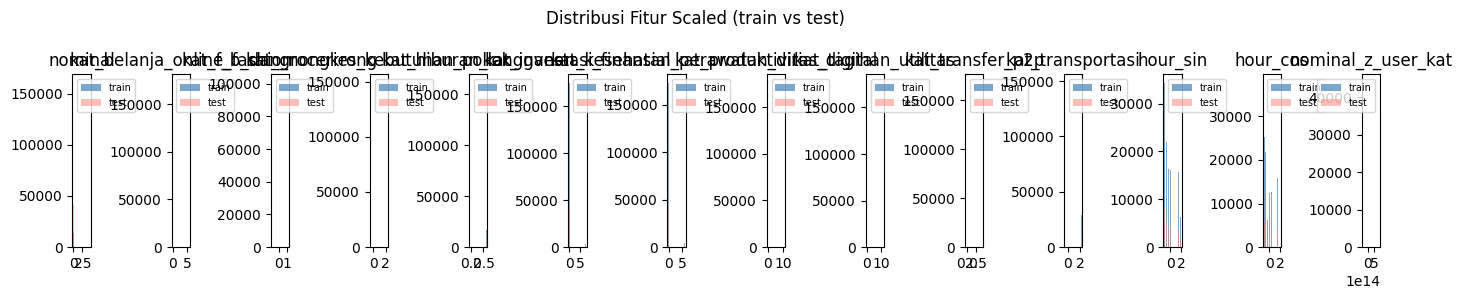

In [11]:
scaler = StandardScaler()
scaler.fit(df_train[FEATURE_COLS])

for df_phase in [df_train, df_threshold, df_test]:
    scaled = scaler.transform(df_phase[FEATURE_COLS])
    for i, col in enumerate(FEATURE_COLS):
        df_phase[f'{col}_scaled'] = scaled[:, i]

fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(14, 3))
for ax, col in zip(axes, SCALED_COLS):
    ax.hist(df_train[col], bins=40, alpha=0.7, color='steelblue', label='train')
    ax.hist(df_test[col],  bins=40, alpha=0.5, color='salmon',    label='test')
    ax.set_title(col.replace('_scaled', ''))
    ax.legend(fontsize=7)
plt.suptitle('Distribusi Fitur Scaled (train vs test)')
plt.tight_layout()
plt.show()

## Save

In [12]:
KEEP_COLS = (
    ['id_transaksi', 'id_user', 'timestamp', 'kategori_detail', 'nominal', 'label_anomali', 'phase']
    + FEATURE_COLS + SCALED_COLS
)

df_train[KEEP_COLS].to_csv(f'{DATA_DIR}/pre_train.csv', index=False)
df_threshold[KEEP_COLS].to_csv(f'{DATA_DIR}/pre_threshold.csv', index=False)
df_test[KEEP_COLS].to_csv(f'{DATA_DIR}/pre_test.csv', index=False)

joblib.dump({
    'scaler'          : scaler,
    'ohe'             : ohe,
    'ohe_cols'        : OHE_COLS,
    'kat_cap'         : kat_cap,
    'feature_cols'    : FEATURE_COLS,
    'scaled_cols'     : SCALED_COLS,
    'feature_weights' : FEATURE_WEIGHTS,
    'z_stats'         : _z_stats,
}, f'{MODEL_DIR}/preprocessing_meta.pkl')

print(f"pre_train.csv     → {len(df_train):,} rows")
print(f"pre_threshold.csv → {len(df_threshold):,} rows")
print(f"pre_test.csv      → {len(df_test):,} rows")
print(f"preprocessing_meta.pkl saved  ({len(FEATURE_COLS)} features)")

pre_train.csv     → 178,055 rows
pre_threshold.csv → 45,512 rows
pre_test.csv      → 43,925 rows
preprocessing_meta.pkl saved  (14 features)
